In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = r'C:\Users\My Pc\OneDrive\Documents\dataset.csv'

df = pd.read_csv(file_path)

print(df.head())
try:
    df = pd.read_csv(file_path)
    print("Veri seti başarıyla yüklendi.")
    print(f"Toplam {df.shape[0]} satır ve {df.shape[1]} sütun bulunmaktadır.")
except FileNotFoundError:
    print(f"HATA: '{file_path}' adında bir dosya bulunamadı.")
    print("Lütfen dosya adını ve yolunu kontrol edin.")

   Year LocationAbbr      LocationDesc GeographicLevel DataSource  \
0  2020           AK            Denali          County       NVSS   
1  2020           CA        California           State       NVSS   
2  2020           CO       Park County          County       NVSS   
3  2020           FL     Walton County          County       NVSS   
4  2020           GA  Whitfield County          County       NVSS   

                     Class                    Topic  Data_Value  \
0  Cardiovascular Diseases  Heart Disease Mortality       348.8   
1  Cardiovascular Diseases  Heart Disease Mortality       230.1   
2  Cardiovascular Diseases  Heart Disease Mortality       135.9   
3  Cardiovascular Diseases  Heart Disease Mortality       126.5   
4  Cardiovascular Diseases  Heart Disease Mortality       155.1   

          Data_Value_Unit                                    Data_Value_Type  \
0  per 100,000 population  Age-adjusted, Spatially Smoothed, 3-year Avera...   
1  per 100,000 populat

In [4]:
df_clean = df[df['GeographicLevel'] == 'County'].copy()
print(f"Sadece ilçe (County) verisi seçildi. Satır sayısı: {df_clean.shape[0]}")

cols_to_drop = [
    'Year', 'DataSource', 'Class', 'Topic', 'GeographicLevel',
    'Data_Value_Type', 'Data_Value_Unit', 'Data_Value_Footnote_Symbol',
    'Data_Value_Footnote', 'StratificationCategory1', 'StratificationCategory2',
    'TopicID', 'ClassID', 'TopicType',
    'LocationDesc'
]

existing_cols_to_drop = [col for col in cols_to_drop if col in df_clean.columns]
df_clean = df_clean.drop(columns=existing_cols_to_drop)

df_clean = df_clean.rename(columns={
    'LocationAbbr': 'State',
    'LocationID': 'FIPS',         
    'Data_Value': 'Mortality_Rate',
    'Stratification1': 'Gender',
    'Stratification2': 'Race_Ethnicity'
})

print("Gereksiz sütunlar atıldı ve sütunlar yeniden adlandırıldı.")
df_clean.head()

Sadece ilçe (County) verisi seçildi. Satır sayısı: 77424
Gereksiz sütunlar atıldı ve sütunlar yeniden adlandırıldı.


,State,Mortality_Rate,Gender,Race_Ethnicity,FIPS,Y_lat,X_lon,Georeference
0,AK,348.8,Male,White,2068,63.678820,-149.960801,POINT (-149.9608012 63.67881971)
2,CO,135.9,Female,White,8093,39.115616,-105.708698,POINT (-105.7086982 39.11561621)
3,FL,126.5,Female,Asian,12131,30.655966,-86.157457,POINT (-86.15745736 30.65596581)
4,GA,155.1,Female,Hispanic,13313,34.803854,-84.962112,POINT (-84.96211184 34.80385386)
5,GA,NaN,Female,Asian,13299,31.051889,-82.420394,POINT (-82.4203935 31.05188914)


In [5]:
print("\nEksik Veri Kontrolü (Temizlemeden Önce):")
print(df_clean.isnull().sum())


df_clean.dropna(subset=['Mortality_Rate'], inplace=True)
print(f"\n'Mortality_Rate' sütununda eksik olan satırlar silindi. Yeni satır sayısı: {df_clean.shape[0]}")


print("\nVeri Tipi Kontrolü:")
df_clean.info()

if df_clean['Mortality_Rate'].dtype == 'object':
    df_clean['Mortality_Rate'] = pd.to_numeric(df_clean['Mortality_Rate'], errors='coerce')
    df_clean.dropna(subset=['Mortality_Rate'], inplace=True)


Eksik Veri Kontrolü (Temizlemeden Önce):
State                 0
Mortality_Rate    43993
Gender                0
Race_Ethnicity        0
FIPS                  0
Y_lat                 0
X_lon                 0
Georeference          0
dtype: int64

'Mortality_Rate' sütununda eksik olan satırlar silindi. Yeni satır sayısı: 33431

Veri Tipi Kontrolü:
<class 'pandas.core.frame.DataFrame'>
Index: 33431 entries, 0 to 78790
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   State           33431 non-null  object 
 1   Mortality_Rate  33431 non-null  float64
 2   Gender          33431 non-null  object 
 3   Race_Ethnicity  33431 non-null  object 
 4   FIPS            33431 non-null  int64  
 5   Y_lat           33431 non-null  float64
 6   X_lon           33431 non-null  float64
 7   Georeference    33431 non-null  object 
dtypes: float64(3), int64(1), object(4)
memory usage: 2.3+ MB


In [6]:
df_clean['FIPS'] = df_clean['FIPS'].astype(str)

df_clean['FIPS'] = df_clean['FIPS'].str.zfill(5)

print("\nFIPS kodları 5 haneli metin formatına dönüştürüldü (örn: '01001').")
print(df_clean[['State', 'FIPS', 'Gender', 'Race_Ethnicity']].head())


FIPS kodları 5 haneli metin formatına dönüştürüldü (örn: '01001').
  State   FIPS   Gender Race_Ethnicity
0    AK  02068     Male          White
2    CO  08093   Female          White
3    FL  12131   Female          Asian
4    GA  13313   Female       Hispanic
6    IA  19093  Overall       Hispanic


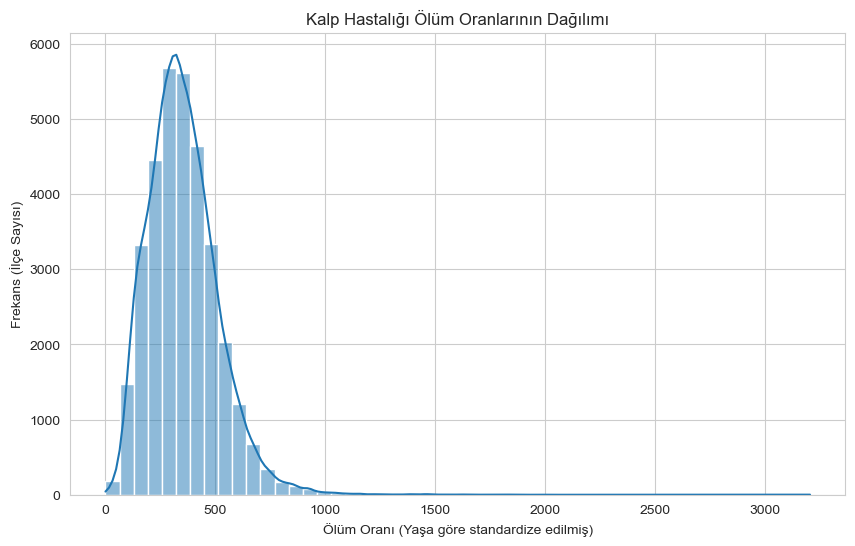

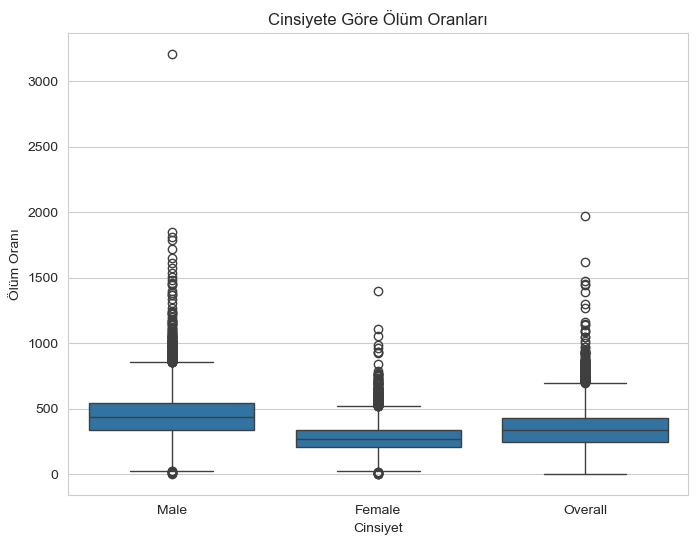

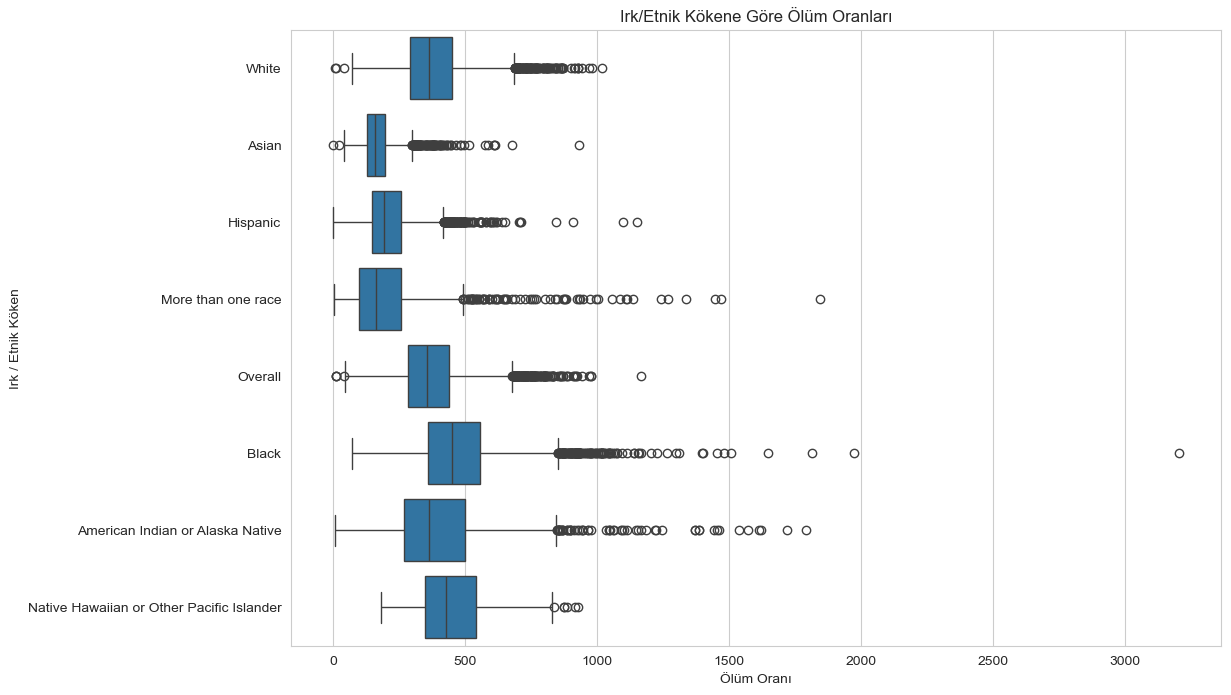

In [7]:
sns.set_style("whitegrid")

# 1. Hedef Değişkenin (Mortality_Rate) Dağılımı
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['Mortality_Rate'], kde=True, bins=50)
plt.title('Kalp Hastalığı Ölüm Oranlarının Dağılımı')
plt.xlabel('Ölüm Oranı (Yaşa göre standardize edilmiş)')
plt.ylabel('Frekans (İlçe Sayısı)')
plt.show()

# 2. Cinsiyete Göre Ölüm Oranları
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_clean, x='Gender', y='Mortality_Rate')
plt.title('Cinsiyete Göre Ölüm Oranları')
plt.xlabel('Cinsiyet')
plt.ylabel('Ölüm Oranı')
plt.show()

# 3. Etnik Köken/Irka Göre Ölüm Oranları
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_clean, y='Race_Ethnicity', x='Mortality_Rate', orient='h')
plt.title('Irk/Etnik Kökene Göre Ölüm Oranları')
plt.xlabel('Ölüm Oranı')
plt.ylabel('Irk / Etnik Köken')
plt.show()

In [8]:
import pandas as pd
import sys
import openpyxl

files_to_check = [r"C:\Users\My Pc\OneDrive\Documents\Poverty2023.xlsx",r"C:\Users\My Pc\OneDrive\Documents\Education2023.xlsx", r"C:\Users\My Pc\OneDrive\Documents\Unemployment2023.xlsx"]


for file in files_to_check:
    try:
        xls = pd.ExcelFile(file)
        
        sheet_names = xls.sheet_names
        print(f"Bulunan Sekme Adları: {sheet_names}")
        
        data_sheet_name = None
        for name in sheet_names:
            if "description" not in name.lower() and "readme" not in name.lower():
                data_sheet_name = name
                print(f"Veri sekmesi olarak '{data_sheet_name}' seçildi.")
                break
        
        if not data_sheet_name:
            print("Veri sekmesi bulunamadı.")
            continue

        print(f"\n'{data_sheet_name}' sekmesinin ilk 10 satırı (HAM GÖRÜNÜM):")
        df_preview = pd.read_excel(xls, sheet_name=data_sheet_name, header=None, nrows=10)
        print(df_preview)

        try:
            header_row_index = 4
            df_cols = pd.read_excel(xls, sheet_name=data_sheet_name, header=header_row_index)
            print(f"\n'{data_sheet_name}' (Başlık Satırı: {header_row_index}) Sütun Listesi:")
            for col in df_cols.columns:
                print(col)
        except Exception as e:
            print(f"Başlıklar okunurken hata: {e}.")

    except FileNotFoundError:
        print(f"HATA: '{file}' dosyası bulunamadı.")
    except Exception as e:
        print(f"Bir hata oluştu: {e}")

Bulunan Sekme Adları: ['Poverty Data 2023', 'Variable Descriptions']
Veri sekmesi olarak 'Poverty Data 2023' seçildi.

'Poverty Data 2023' sekmesinin ilk 10 satırı (HAM GÖRÜNÜM):
                                                  0      1               2   \
0  Poverty estimates for United States, States, a...    NaN             NaN   
1  Source: U.S. Department of Commerce, Bureau of...    NaN             NaN   
2  Poverty status is determined at the family lev...    NaN             NaN   
3  This table was prepared by USDA, Economic Rese...    NaN             NaN   
4                                          FIPS_Code  Stabr       Area_Name   
5                                              00000     US   United States   
6                                              01000     AL         Alabama   
7                                              01001     AL  Autauga County   
8                                              01003     AL  Baldwin County   
9                              

In [9]:
#  BÖLÜM 2: SOSYOEKONOMİK VERİLERİ YÜKLEME VE BİRLEŞTİRME ---
try:
    #  2.1: GELİR (INCOME) VERİSİ
    INCOME_DOSYA_ADI = r"C:\Users\My Pc\OneDrive\Documents\Unemployment2023.xlsx"
    INCOME_SEKME_ADI = "Unemployment Med HH Income"
    INCOME_BASLIK_SATIRI = 4 
    
    df_income = pd.read_excel(INCOME_DOSYA_ADI, sheet_name=INCOME_SEKME_ADI, header=INCOME_BASLIK_SATIRI, dtype={'FIPS_Code': str})
    INCOME_SUTUNLARI = {
        'FIPS_Code': 'FIPS',
        'Median_Household_Income_2022': 'Median_Income_2022'
    }
    df_income = df_income[list(INCOME_SUTUNLARI.keys())].copy()
    df_income.rename(columns=INCOME_SUTUNLARI, inplace=True)

    df_income['FIPS'] = df_income['FIPS'].str.zfill(5)
    print(f"'{INCOME_DOSYA_ADI}' yüklendi ve işlendi.")

    #  2.2: EĞİTİM (EDUCATION) VERİSİ
    EDUCATION_DOSYA_ADI = r"C:\Users\My Pc\OneDrive\Documents\Education2023.xlsx"
    EDUCATION_SEKME_ADI = "Education 1970 to 2023"
    EDUCATION_BASLIK_SATIRI = 3 
    
    df_edu = pd.read_excel(EDUCATION_DOSYA_ADI, sheet_name=EDUCATION_SEKME_ADI, header=EDUCATION_BASLIK_SATIRI, dtype={'FIPS Code': str})
    EDUCATION_SUTUNLARI = {
        'FIPS Code': 'FIPS', 
        "Percent of adults with a bachelor's degree or higher, 2019-23": 'Edu_Bach_Pct_2019-23'
    }
    df_edu = df_edu[list(EDUCATION_SUTUNLARI.keys())].copy()
    df_edu.rename(columns=EDUCATION_SUTUNLARI, inplace=True)
    df_edu['FIPS'] = df_edu['FIPS'].str.zfill(5)
    print(f"'{EDUCATION_DOSYA_ADI}' yüklendi ve işlendi.")
    
    #  2.3: YOKSULLUK (POVERTY) VERİSİ 
    POVERTY_DOSYA_ADI = r"C:\Users\My Pc\OneDrive\Documents\Poverty2023.xlsx"
    POVERTY_SEKME_ADI = "Poverty Data 2023"
    POVERTY_BASLIK_SATIRI = 4 
    
    df_poverty = pd.read_excel(POVERTY_DOSYA_ADI, sheet_name=POVERTY_SEKME_ADI, header=POVERTY_BASLIK_SATIRI, dtype={'FIPS_Code': str})
    POVERTY_SUTUNLARI = {
        'FIPS_Code': 'FIPS',
        'PCTPOVALL_2023': 'Poverty_Pct_2023' 
    }
    df_poverty = df_poverty[list(POVERTY_SUTUNLARI.keys())].copy()
    df_poverty.rename(columns=POVERTY_SUTUNLARI, inplace=True)
    df_poverty['FIPS'] = df_poverty['FIPS'].str.zfill(5)
    print(f"'{POVERTY_DOSYA_ADI}' yüklendi ve işlendi.")

except FileNotFoundError as e:
    print(f"HATA: Dosya bulunamadı -> {e}. ")
    raise SystemExit("Script durduruldu.")
except KeyError as e:
    print(f"HATA: Sütun adı bulunamadı -> {e}.")
    raise SystemExit("Script durduruldu.")
except Exception as e:
    print(f"Genel bir hata oluştu: {e}")
    raise SystemExit("Script durduruldu.")

#  BÖLÜM 3: TÜM VERİLERİ BİRLEŞTİRME VE KAYDETME
print("Tüm veriler birleştiriliyor...")

df_socio_merged = pd.merge(df_income, df_edu, on='FIPS', how='outer')
df_socio_merged = pd.merge(df_socio_merged, df_poverty, on='FIPS', how='outer')

df_final_merged = pd.merge(df_clean, df_socio_merged, on='FIPS', how='left')

print("Birleştirme tamamlandı. Son kontroller yapılıyor...")

print(f"Birleştirmeden önce satır sayısı: {df_clean.shape[0]}")
print(f"Birleştirmeden sonra satır sayısı: {df_final_merged.shape[0]}")

original_rows = df_final_merged.shape[0]
df_final_merged.dropna(inplace=True) 
final_rows = df_final_merged.shape[0]

print(f"Sosyoekonomik verisi eksik olan {original_rows - final_rows} satır silindi.")
print(f"Veri setinin son boyutu: {df_final_merged.shape}")

'C:\Users\My Pc\OneDrive\Documents\Unemployment2023.xlsx' yüklendi ve işlendi.
'C:\Users\My Pc\OneDrive\Documents\Education2023.xlsx' yüklendi ve işlendi.
'C:\Users\My Pc\OneDrive\Documents\Poverty2023.xlsx' yüklendi ve işlendi.
Tüm veriler birleştiriliyor...
Birleştirme tamamlandı. Son kontroller yapılıyor...
Birleştirmeden önce satır sayısı: 33431
Birleştirmeden sonra satır sayısı: 33431
Sosyoekonomik verisi eksik olan 401 satır silindi.
Veri setinin son boyutu: (33030, 11)


In [10]:

output_file = "tum_veriler_temiz_birlesmis.csv"
df_final_merged.to_csv(output_file, index=False)

print(f"\n--- FAZ 1 TAMAMLANDI ---")
print(f"Tüm temizlenmiş ve birleştirilmiş veriler '{output_file}' olarak kaydedildi.")


--- FAZ 1 TAMAMLANDI ---
Tüm temizlenmiş ve birleştirilmiş veriler 'tum_veriler_temiz_birlesmis.csv' olarak kaydedildi.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report


df = pd.read_csv("tum_veriler_temiz_birlesmis.csv")

df_model = df.drop(columns=['State', 'FIPS'])

threshold = df_model['Mortality_Rate'].median()
df_model['Risk_Class'] = (df_model['Mortality_Rate'] > threshold).astype(int)

df_model = df_model.drop(columns=['Mortality_Rate'])

print(f"Hedef değişken 'Risk_Class' oluşturuldu. Eşik Değer (Medyan): {threshold}")
print(df_model['Risk_Class'].value_counts())

df_encoded = pd.get_dummies(df_model, drop_first=True)

X = df_encoded.drop(columns=['Risk_Class'])
y = df_encoded['Risk_Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Sadece transform!

print(f"\nVeri Sayısallaştırıldı ve Ölçeklendi.")
print(f"Orijinal Özellik Sayısı: {X_train.shape[1]}")

pca = PCA(n_components=0.90) 

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

n_components = pca.n_components_
print(f"\nPCA Uygulandı.")
print(f"Varyansın %90'ını korumak için gereken bileşen sayısı: {n_components}")
print(f"Boyut İndirgeme Oranı: {X_train.shape[1]} özellikten -> {n_components} bileşene düştü.")

results = []

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "k-NN (k=5)": KNeighborsClassifier(n_neighbors=5)
}

datasets = [
    ("Tüm Özellikler (Scaled)", X_train_scaled, X_test_scaled),
    ("PCA ile İndirgenmiş", X_train_pca, X_test_pca)
]

print(" MODEL PERFORMANS KARŞILAŞTIRMASI ---")

for model_name, model in models.items():
    for data_name, X_tr, X_te in datasets:
        
        start_time = time.time()

        model.fit(X_tr, y_train)

        y_pred = model.predict(X_te)

        end_time = time.time()
        elapsed_time = end_time - start_time

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        results.append({
            "Model": model_name,
            "Veri Yaklaşımı": data_name,
            "Özellik Sayısı": X_tr.shape[1],
            "Accuracy": acc,
            "F1 Score": f1,
            "Süre (sn)": elapsed_time
        })

df_results = pd.DataFrame(results)
print(df_results)



Hedef değişken 'Risk_Class' oluşturuldu. Eşik Değer (Medyan): 339.3
Risk_Class
0    16516
1    16514
Name: count, dtype: int64

Veri Sayısallaştırıldı ve Ölçeklendi.
Orijinal Özellik Sayısı: 3142

PCA Uygulandı.
Varyansın %90'ını korumak için gereken bileşen sayısı: 2819
Boyut İndirgeme Oranı: 3142 özellikten -> 2819 bileşene düştü.
 MODEL PERFORMANS KARŞILAŞTIRMASI ---
                 Model           Veri Yaklaşımı  Özellik Sayısı  Accuracy  \
0  Logistic Regression  Tüm Özellikler (Scaled)            3142  0.882077   
1  Logistic Regression      PCA ile İndirgenmiş            2819  0.782470   
2           k-NN (k=5)  Tüm Özellikler (Scaled)            3142  0.697094   
3           k-NN (k=5)      PCA ile İndirgenmiş            2819  0.700272   

   F1 Score  Süre (sn)  
0  0.880869   3.054072  
1  0.780242  11.007259  
2  0.696956  16.136200  
3  0.702524  18.786083  


Veri hazırlanıyor...
Veri hazır. Özellik Sayısı: 3142

--- PCA ANALİZİ ---
Seçilen Bileşen Sayısı: 2819
İndirgeme Oranı: 3142 özellik -> 2819 bileşen


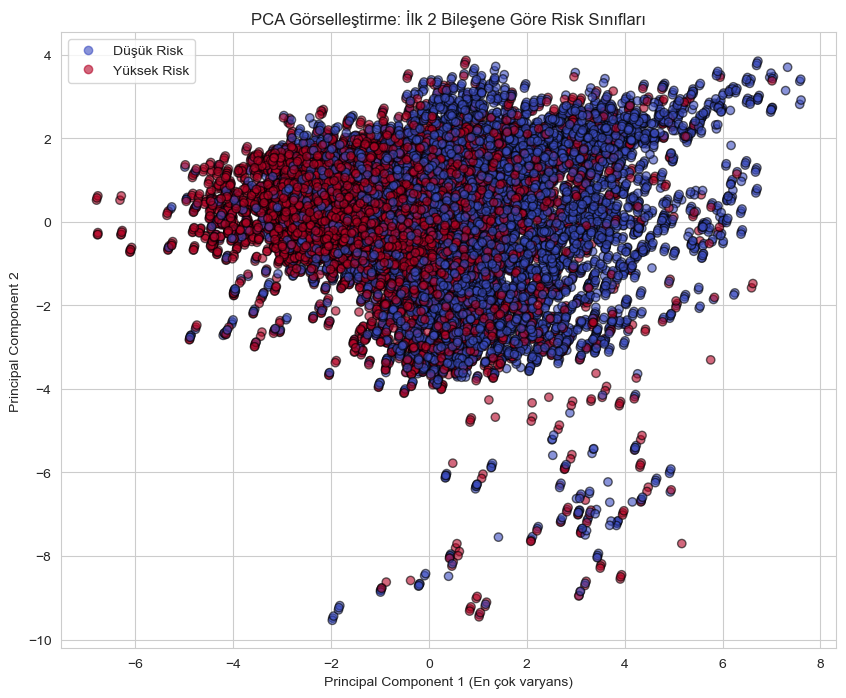

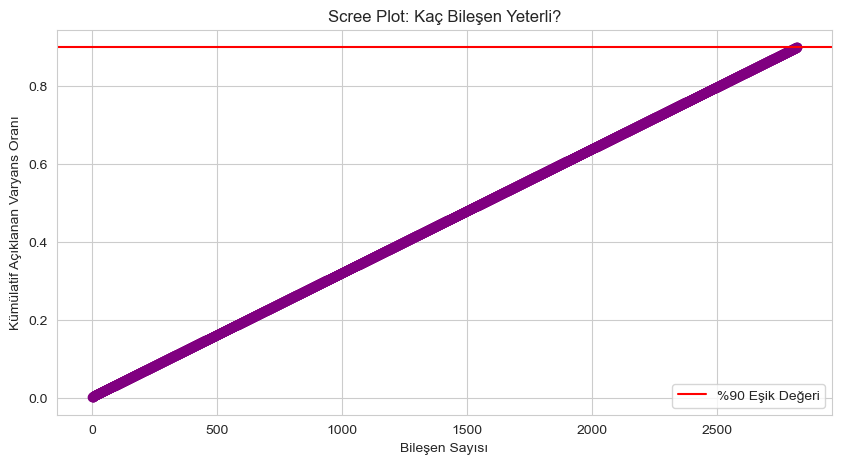


--- MODELLER EĞİTİLİYOR ---

Sonuç Tablosu:
                 Model                Veri Seti  Accuracy  F1 Score  ROC AUC  \
0  Logistic Regression  Tüm Özellikler (Scaled)  0.882077  0.880869        0   
1  Logistic Regression          PCA İndirgenmiş  0.782470  0.780242        0   
2           k-NN (k=5)  Tüm Özellikler (Scaled)  0.697094  0.696956        0   
3           k-NN (k=5)          PCA İndirgenmiş  0.700272  0.702524        0   

   Süre (sn)  
0   2.899172  
1   9.487171  
2  18.189733  
3  17.966815  


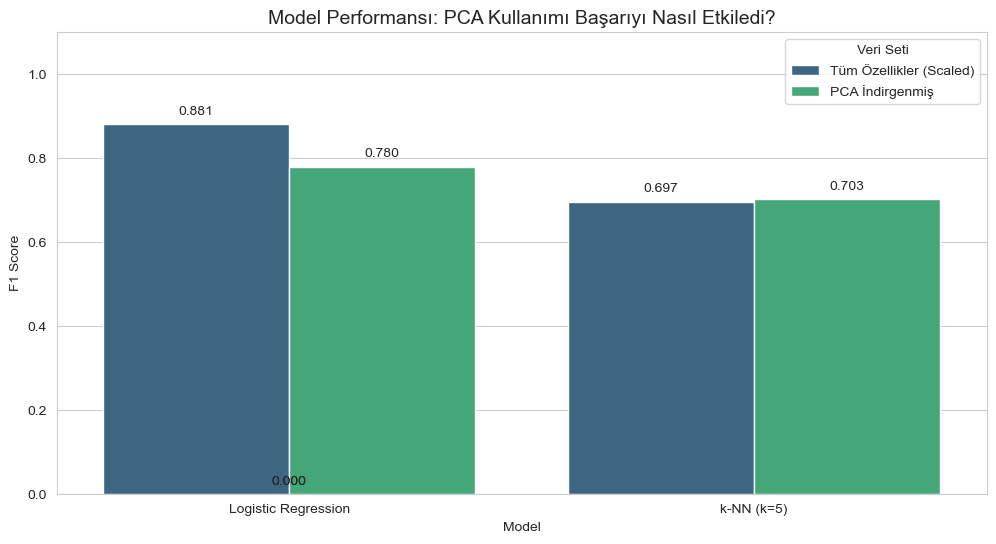

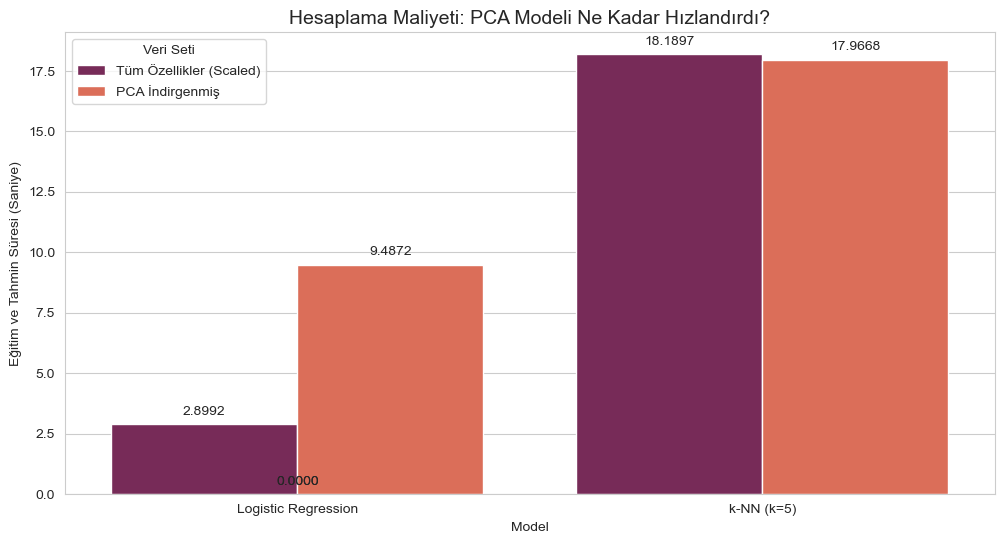

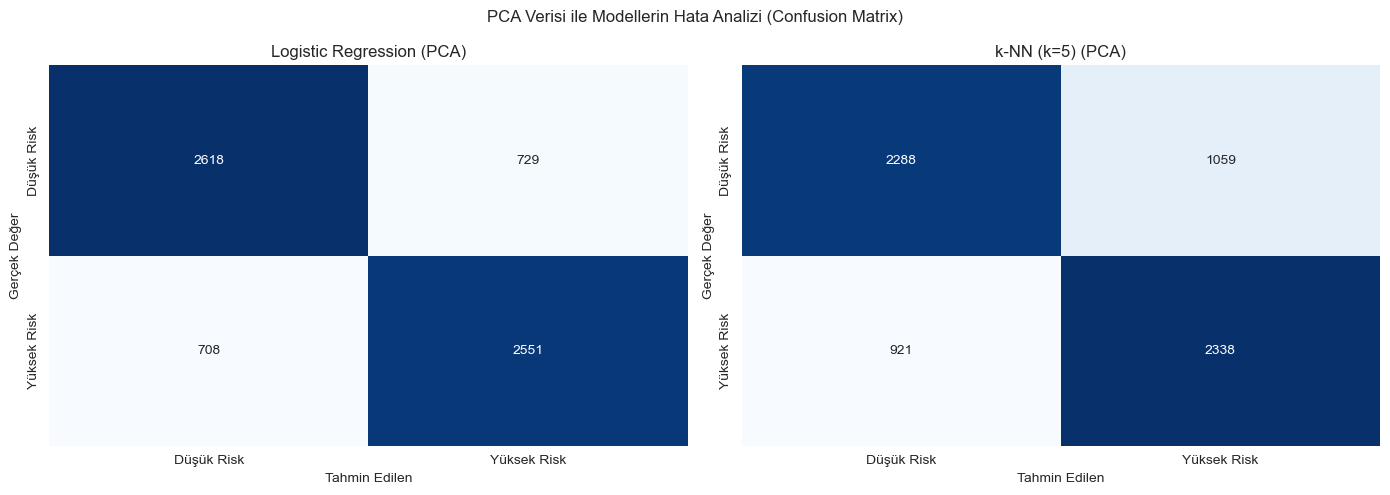

In [14]:
from sklearn.metrics import confusion_matrix
print("Veri hazırlanıyor...")
df = pd.read_csv("tum_veriler_temiz_birlesmis.csv")

df_model = df.drop(columns=['State', 'FIPS'])


threshold = df_model['Mortality_Rate'].median()
df_model['Risk_Class'] = (df_model['Mortality_Rate'] > threshold).astype(int)
df_model = df_model.drop(columns=['Mortality_Rate'])

df_encoded = pd.get_dummies(df_model, drop_first=True)

# X ve y ayrımı
X = df_encoded.drop(columns=['Risk_Class'])
y = df_encoded['Risk_Class']

# Eğitim/Test Ayrımı
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ölçeklendirme
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Veri hazır. Özellik Sayısı: {X_train.shape[1]}")

print("\n--- PCA ANALİZİ ---")

pca = PCA(n_components=0.90)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Seçilen Bileşen Sayısı: {pca.n_components_}")
print(f"İndirgeme Oranı: {X_train.shape[1]} özellik -> {pca.n_components_} bileşen")

pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_train_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y_train, cmap='coolwarm', alpha=0.6, edgecolor='k')
plt.title('PCA Görselleştirme: İlk 2 Bileşene Göre Risk Sınıfları')
plt.xlabel('Principal Component 1 (En çok varyans)')
plt.ylabel('Principal Component 2')
plt.legend(handles=scatter.legend_elements()[0], labels=['Düşük Risk', 'Yüksek Risk'])
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--', color='purple')
plt.axhline(y=0.90, color='r', linestyle='-', label='%90 Eşik Değeri')
plt.title('Scree Plot: Kaç Bileşen Yeterli?')
plt.xlabel('Bileşen Sayısı')
plt.ylabel('Kümülatif Açıklanan Varyans Oranı')
plt.legend()
plt.show()


# 3. MODEL EĞİTİMİ VE KARŞILAŞTIRMA
results = []

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "k-NN (k=5)": KNeighborsClassifier(n_neighbors=5)
}

datasets = [
    ("Tüm Özellikler (Scaled)", X_train_scaled, X_test_scaled),
    ("PCA İndirgenmiş", X_train_pca, X_test_pca)
]

print("\n--- MODELLER EĞİTİLİYOR ---")

for model_name, model in models.items():
    for data_name, X_tr, X_te in datasets:
        
        start_time = time.time()
        model.fit(X_tr, y_train)
        y_pred = model.predict(X_te)
        end_time = time.time()
       
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        try:
            y_prob = model.predict_proba(X_te)[:, 1]
            roc = roc_auc_score(y_test, y_prob)
        except:
            roc = 0 
            
        results.append({
            "Model": model_name,
            "Veri Seti": data_name,
            "Accuracy": acc,
            "F1 Score": f1,
            "ROC AUC": roc,
            "Süre (sn)": end_time - start_time
        })

df_results = pd.DataFrame(results)
print("\nSonuç Tablosu:")
print(df_results)


# 4. SONUÇLARIN GÖRSELLEŞTİRİLMESİ
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df_results, x="Model", y="F1 Score", hue="Veri Seti", palette="viridis")
plt.title("Model Performansı: PCA Kullanımı Başarıyı Nasıl Etkiledi?", fontsize=14)
plt.ylim(0, 1.1)

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.3f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')
plt.show()

plt.figure(figsize=(12, 6))
ax2 = sns.barplot(data=df_results, x="Model", y="Süre (sn)", hue="Veri Seti", palette="rocket")
plt.title("Hesaplama Maliyeti: PCA Modeli Ne Kadar Hızlandırdı?", fontsize=14)
plt.ylabel("Eğitim ve Tahmin Süresi (Saniye)")

for p in ax2.patches:
    ax2.annotate(format(p.get_height(), '.4f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')
plt.show()


# 5. CONFUSION MATRIX 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PCA Verisi ile Modellerin Hata Analizi (Confusion Matrix)')

for i, (model_name, model) in enumerate(models.items()):
    model.fit(X_train_pca, y_train)
    y_pred_pca = model.predict(X_test_pca)
    
    cm = confusion_matrix(y_test, y_pred_pca)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'{model_name} (PCA)')
    axes[i].set_xlabel('Tahmin Edilen')
    axes[i].set_ylabel('Gerçek Değer')
    axes[i].set_xticklabels(['Düşük Risk', 'Yüksek Risk'])
    axes[i].set_yticklabels(['Düşük Risk', 'Yüksek Risk'])

plt.tight_layout()
plt.show()